# Frontier-Based Exploration Prototype

This notebook shows the core idea of **frontier-based exploration** on a 2D occupancy grid.

We keep everything simple:
- `-1` = unknown
- `0` = free
- `100` = occupied

No ROS code is used.

## Step 1 - Define a sample occupancy grid

What we do: Create a small map where the center is known, some cells are obstacles, and the outside is unknown.

Why it matters: Exploration works by expanding from known free space into unknown space.

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Create a 12x12 grid. Start with all cells unknown (-1).
grid = np.full((12, 12), -1, dtype=int)

# Mark a central area as known free space (0).
grid[3:9, 3:9] = 0

# Add a few occupied cells (100) as obstacles inside the free region.
obstacles = [(4, 5), (5, 5), (6, 5), (7, 7), (3, 7)]
for r, c in obstacles:
    grid[r, c] = 100

print('Grid shape:', grid.shape)
print('Value legend: -1 unknown, 0 free, 100 occupied')
grid

Grid shape: (12, 12)
Value legend: -1 unknown, 0 free, 100 occupied


array([[ -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1],
       [ -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1],
       [ -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1],
       [ -1,  -1,  -1,   0,   0,   0,   0, 100,   0,  -1,  -1,  -1],
       [ -1,  -1,  -1,   0,   0, 100,   0,   0,   0,  -1,  -1,  -1],
       [ -1,  -1,  -1,   0,   0, 100,   0,   0,   0,  -1,  -1,  -1],
       [ -1,  -1,  -1,   0,   0, 100,   0,   0,   0,  -1,  -1,  -1],
       [ -1,  -1,  -1,   0,   0,   0,   0, 100,   0,  -1,  -1,  -1],
       [ -1,  -1,  -1,   0,   0,   0,   0,   0,   0,  -1,  -1,  -1],
       [ -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1],
       [ -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1],
       [ -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1]])

## Step 2 - Visualize the grid

What we do: Plot the occupancy grid using clear colors.

Why it matters: Visualization helps us verify the map before running any frontier logic.

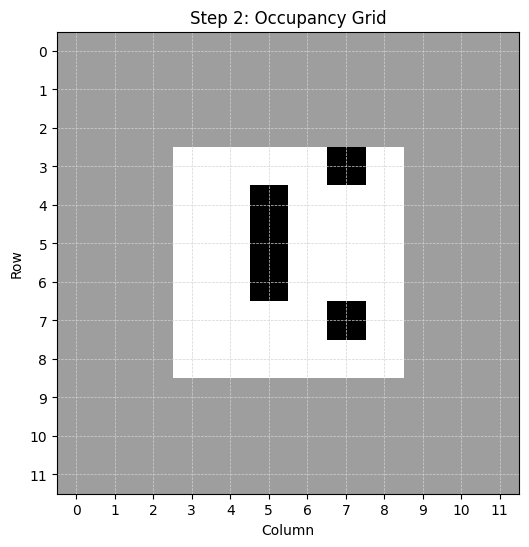

In [70]:
def plot_grid(base_grid, title='Occupancy Grid'):
    """Plot occupancy grid with fixed colors for unknown/free/occupied."""
    # We map values to color bins using boundaries:
    # -1 -> gray, 0 -> white, 100 -> black
    cmap = ListedColormap(['#9e9e9e', '#ffffff', '#000000'])
    bounds = [-1.5, -0.5, 0.5, 100.5]
    norm = BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(6, 6))
    plt.imshow(base_grid, cmap=cmap, norm=norm, origin='upper')
    plt.title(title)
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.xticks(range(base_grid.shape[1]))
    plt.yticks(range(base_grid.shape[0]))
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.show()

plot_grid(grid, title='Step 2: Occupancy Grid')

## Step 3 - Implement frontier detection

What we do: Detect frontier cells using the rule: a cell is a frontier if it is FREE (`0`) and has at least one UNKNOWN (`-1`) neighbor.

Why it matters: Frontiers are the boundary between explored and unexplored space, so they are natural exploration targets.

In [71]:
def get_neighbors_8(row, col, rows, cols):
    """Return all valid 8-connected neighbors of (row, col)."""
    neighbors = []

    # dr and dc move in all directions including diagonals.
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            # Skip the center cell itself.
            if dr == 0 and dc == 0:
                continue

            nr, nc = row + dr, col + dc

            # Keep only coordinates inside the map boundaries.
            if 0 <= nr < rows and 0 <= nc < cols:
                neighbors.append((nr, nc))

    return neighbors


def detect_frontiers(grid: np.ndarray):
    """
    A frontier cell is free (0) and touches at least one unknown (-1) cell
    in its 8-connected neighborhood.
    """
    rows, cols = grid.shape
    frontiers = []

    # Check every cell in the map.
    for r in range(rows):
        for c in range(cols):
            # Rule 1: cell must be free.
            if grid[r, c] != 0:
                continue

            # Rule 2: at least one unknown neighbor.
            neighbors = get_neighbors_8(r, c, rows, cols)
            has_unknown_neighbor = any(grid[nr, nc] == -1 for nr, nc in neighbors)

            if has_unknown_neighbor:
                frontiers.append((r, c))

    return frontiers

frontier_cells = detect_frontiers(grid)
print('Number of frontier cells:', len(frontier_cells))
print('Frontier cells:', frontier_cells)

Number of frontier cells: 19
Frontier cells: [(3, 3), (3, 4), (3, 5), (3, 6), (3, 8), (4, 3), (4, 8), (5, 3), (5, 8), (6, 3), (6, 8), (7, 3), (7, 8), (8, 3), (8, 4), (8, 5), (8, 6), (8, 7), (8, 8)]


## Step 4 - Visualize frontier cells

What we do: Plot the same map and overlay frontier cells in red.

Why it matters: It confirms that our detection logic finds cells exactly on the known/unknown boundary.

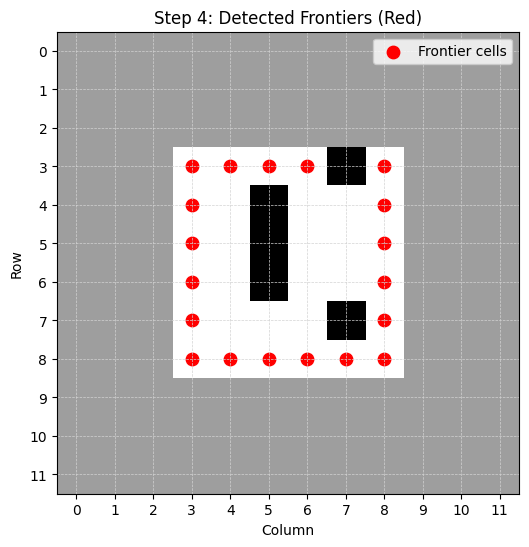

In [72]:
def plot_grid_with_frontiers(base_grid, frontiers, title='Grid with Frontiers'):
    """Plot the occupancy grid and mark frontier cells in red."""
    cmap = ListedColormap(['#9e9e9e', '#ffffff', '#000000'])
    bounds = [-1.5, -0.5, 0.5, 100.5]
    norm = BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(6, 6))
    plt.imshow(base_grid, cmap=cmap, norm=norm, origin='upper')

    if frontiers:
        fr = [r for r, _ in frontiers]
        fc = [c for _, c in frontiers]
        plt.scatter(fc, fr, c='red', s=80, label='Frontier cells')

    plt.title(title)
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.xticks(range(base_grid.shape[1]))
    plt.yticks(range(base_grid.shape[0]))
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(loc='upper right')
    plt.show()

plot_grid_with_frontiers(grid, frontier_cells, title='Step 4: Detected Frontiers (Red)')

## Step 5 - Cluster frontier cells (simple BFS)

What we do: Group nearby frontier cells into clusters using BFS with 8-connected neighbors.

Why it matters: A robot usually chooses between frontier regions (clusters), not isolated single cells.

In [73]:
from collections import deque

def cluster_frontiers(frontiers, grid_shape):
    """Group frontier cells into 8-connected clusters using BFS."""
    frontier_set = set(frontiers)
    visited = set()
    clusters = []
    rows, cols = grid_shape

    for cell in frontier_set:
        if cell in visited:
            continue

        # Start a new cluster from this unvisited frontier cell.
        queue = deque([cell])
        visited.add(cell)
        cluster = []

        while queue:
            current = queue.popleft()
            cluster.append(current)

            # Only frontier neighbors are added to this cluster.
            r, c = current
            for nbr in get_neighbors_8(r, c, rows, cols):
                if nbr in frontier_set and nbr not in visited:
                    visited.add(nbr)
                    queue.append(nbr)

        clusters.append(cluster)

    return clusters

frontier_clusters = cluster_frontiers(frontier_cells, grid.shape)
print('Number of frontier clusters:', len(frontier_clusters))
for i, cluster in enumerate(frontier_clusters, start=1):
    print(f'Cluster {i}: size={len(cluster)}, cells={cluster}')

Number of frontier clusters: 1
Cluster 1: size=19, cells=[(3, 4), (3, 3), (3, 5), (4, 3), (3, 6), (5, 3), (6, 3), (7, 3), (8, 3), (8, 4), (8, 5), (8, 6), (8, 7), (7, 8), (8, 8), (6, 8), (5, 8), (4, 8), (3, 8)]


## Step 6 - Choose one goal

What we do: Compute each cluster centroid, then choose the cluster whose centroid is closest to a fake robot position.

Why it matters: Exploration needs a decision rule to pick the next place to go.

In [74]:
def cluster_centroid(cluster):
    """Return centroid (row, col) of a cluster as floats."""
    arr = np.array(cluster, dtype=float)
    return tuple(arr.mean(axis=0))


def euclidean(a, b):
    """Simple Euclidean distance between two (row, col) points."""
    return float(np.hypot(a[0] - b[0], a[1] - b[1]))


def choose_best_cluster(clusters, robot_pos):
    """Pick the cluster with centroid closest to the robot position."""
    if not clusters:
        return None, None, None

    best_cluster = None
    best_centroid = None
    best_distance = float('inf')

    for cluster in clusters:
        centroid = cluster_centroid(cluster)
        dist = euclidean(robot_pos, centroid)

        if dist < best_distance:
            best_distance = dist
            best_cluster = cluster
            best_centroid = centroid

    return best_cluster, best_centroid, best_distance

# Fake robot position in (row, col).
# Pick a known free cell to avoid placing the robot inside an obstacle.
robot_position = (5, 4)

# Safety check: robot must start on a free cell (0).
assert grid[robot_position] == 0, "Robot position must be on a free cell (0)."

best_cluster, goal_centroid, goal_distance = choose_best_cluster(frontier_clusters, robot_position)

print('Robot position:', robot_position)
print('Chosen goal centroid (row, col):', goal_centroid)
print('Distance to chosen centroid:', goal_distance)

Robot position: (5, 4)
Chosen goal centroid (row, col): (np.float64(5.631578947368421), np.float64(5.421052631578948))
Distance to chosen centroid: 1.5550828108099117


## Step 7 - Final visualization

What we do: Show map, all frontiers, robot position, and the selected goal point in one figure.

Why it matters: This is the full frontier-exploration decision pipeline in a clear visual form.

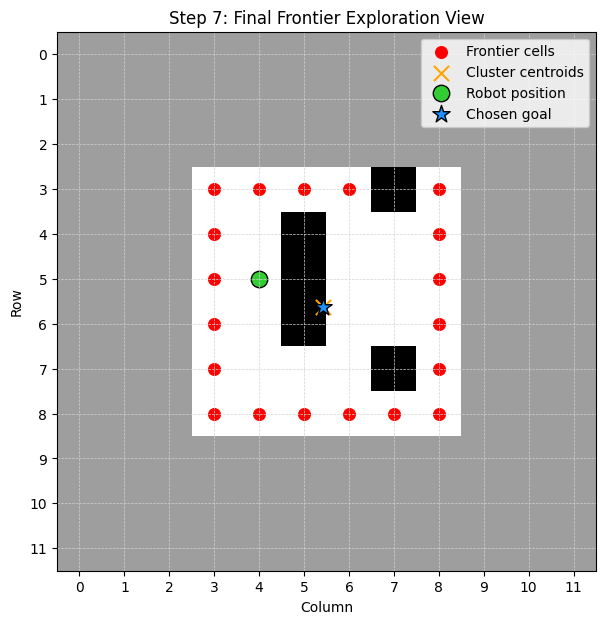

In [75]:
def plot_final_result(base_grid, frontiers, clusters, robot_pos, goal_centroid):
    """Final plot with map, frontiers, robot, and chosen goal centroid."""
    cmap = ListedColormap(['#9e9e9e', '#ffffff', '#000000'])
    bounds = [-1.5, -0.5, 0.5, 100.5]
    norm = BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(7, 7))
    plt.imshow(base_grid, cmap=cmap, norm=norm, origin='upper')

    # Plot all frontier cells in red.
    if frontiers:
        fr = [r for r, _ in frontiers]
        fc = [c for _, c in frontiers]
        plt.scatter(fc, fr, c='red', s=70, label='Frontier cells')

    # Draw each cluster centroid in orange for reference.
    for i, cluster in enumerate(clusters):
        centroid = cluster_centroid(cluster)
        plt.scatter(centroid[1], centroid[0], c='orange', s=120, marker='x',
                    label='Cluster centroids' if i == 0 else None)

    # Plot robot position in green.
    plt.scatter(robot_pos[1], robot_pos[0], c='limegreen', s=140, marker='o',
                edgecolors='black', label='Robot position')

    # Plot chosen goal centroid in blue.
    if goal_centroid is not None:
        plt.scatter(goal_centroid[1], goal_centroid[0], c='dodgerblue', s=170, marker='*',
                    edgecolors='black', label='Chosen goal')

    plt.title('Step 7: Final Frontier Exploration View')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.xticks(range(base_grid.shape[1]))
    plt.yticks(range(base_grid.shape[0]))
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.legend(loc='upper right')
    plt.show()

plot_final_result(grid, frontier_cells, frontier_clusters, robot_position, goal_centroid)

## Wrap-up

In this prototype, we built the core frontier exploration logic:
1. Make an occupancy grid with unknown/free/occupied cells
2. Detect frontier cells
3. Group frontiers into clusters
4. Choose the best cluster goal based on robot distance

This is the key idea behind many exploration systems.

## Step 8 - Simple exploration animation 

What we do: Simulate exploration over time. The robot reveals nearby cells, detects frontiers, chooses a goal, and moves one step at a time.

Why it matters: This makes frontier-based exploration easier to understand because you can see the map changing frame by frame.

Note: We use a simple `plt.pause()` loop (instead of `FuncAnimation`) for reliability in Jupyter notebooks.

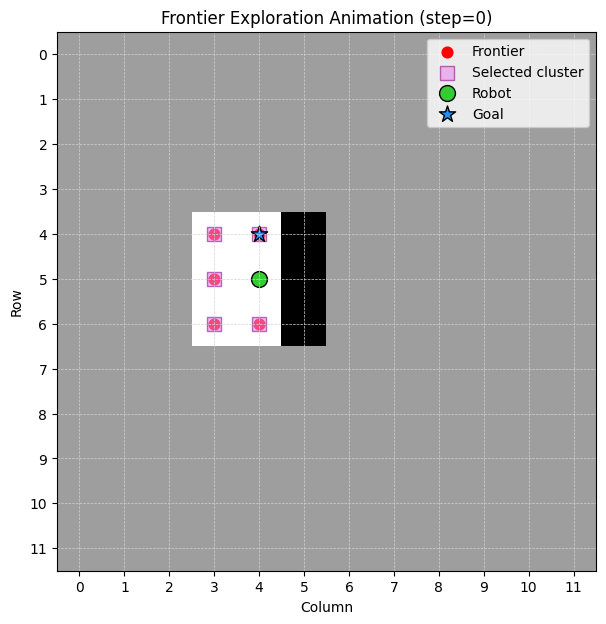

Stopped: all cells have been explored (no unknown cells left).


In [76]:
# -------------------------------
# Simple exploration simulation
# -------------------------------

# In this simulation, we assume the robot does not know the full map at start.
# `true_map` is the hidden world (ground truth).
# `known_map` is what the robot has discovered so far.

# Convert unknown cells from the original demo map into free space for the hidden world.
# This lets exploration eventually finish (no frontiers remain).
true_map = np.where(grid == -1, 0, grid).copy()

# Robot's known map starts fully unknown.
known_map = np.full_like(true_map, -1)

# Start robot on a free cell.
robot_position = (5, 4)
assert true_map[robot_position] == 0, "Robot must start on a free cell in true_map."


def reveal_cells(known_map, true_map, robot_pos, radius=1):
    """Reveal cells around robot (square neighborhood)."""
    rows, cols = known_map.shape
    r0, c0 = robot_pos

    for dr in range(-radius, radius + 1):
        for dc in range(-radius, radius + 1):
            rr, cc = r0 + dr, c0 + dc
            if 0 <= rr < rows and 0 <= cc < cols:
                known_map[rr, cc] = true_map[rr, cc]


def choose_goal_from_cluster(best_cluster, robot_pos, min_goal_distance=2.5):
    """Pick one concrete frontier cell from the chosen cluster.

    We ignore very close frontier cells to avoid tiny inefficient movements.
    If all cells are close, we fall back to the closest one.
    """
    if not best_cluster:
        return None

    # Keep only goals that are far enough from the robot.
    far_enough = [
        cell for cell in best_cluster
        if euclidean(robot_pos, cell) >= min_goal_distance
    ]

    # Fallback: if every frontier is too close, still choose the closest.
    candidate_cells = far_enough if far_enough else list(best_cluster)

    return min(candidate_cells, key=lambda cell: euclidean(robot_pos, cell))


def step_toward_goal(robot_pos, goal_pos, true_map):
    """Move robot by one cell toward goal (8-direction)."""
    if goal_pos is None:
        return robot_pos

    rr, rc = robot_pos
    gr, gc = goal_pos

    # Move at most one step in row and one step in column.
    dr = int(np.sign(gr - rr))
    dc = int(np.sign(gc - rc))

    candidate = (rr + dr, rc + dc)

    # If diagonal move is blocked by obstacle, try axis-aligned alternatives.
    if true_map[candidate] == 100:
        options = []
        if dr != 0:
            options.append((rr + dr, rc))
        if dc != 0:
            options.append((rr, rc + dc))

        for opt in options:
            if 0 <= opt[0] < true_map.shape[0] and 0 <= opt[1] < true_map.shape[1]:
                if true_map[opt] != 100:
                    return opt

        # If all options blocked, stay in place.
        return robot_pos

    return candidate


def draw_frame(ax, known_map, frontiers, robot_pos, goal_pos, step_idx, selected_cluster=None):
    """Draw one animation frame with map + frontiers + robot + goal."""
    cmap = ListedColormap(['#9e9e9e', '#ffffff', '#000000'])
    bounds = [-1.5, -0.5, 0.5, 100.5]
    norm = BoundaryNorm(bounds, cmap.N)

    ax.clear()
    ax.imshow(known_map, cmap=cmap, norm=norm, origin='upper')

    # Frontier cells in red.
    if frontiers:
        fr = [r for r, _ in frontiers]
        fc = [c for _, c in frontiers]
        ax.scatter(fc, fr, c='red', s=60, label='Frontier')

    # Selected cluster cells (used for centroid/goal choice) in violet.
    if selected_cluster:
        cr = [r for r, _ in selected_cluster]
        cc = [c for _, c in selected_cluster]
        ax.scatter(cc, cr, c='violet', s=90, marker='s', alpha=0.55,
                   edgecolors='purple', label='Selected cluster')

    # Robot in green.
    ax.scatter(robot_pos[1], robot_pos[0], c='limegreen', s=130,
               edgecolors='black', label='Robot')

    # Current goal in blue.
    if goal_pos is not None:
        ax.scatter(goal_pos[1], goal_pos[0], c='dodgerblue', s=150, marker='*',
                   edgecolors='black', label='Goal')

    ax.set_title(f'Frontier Exploration Animation (step={step_idx})')
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_xticks(range(known_map.shape[1]))
    ax.set_yticks(range(known_map.shape[0]))
    ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
    ax.legend(loc='upper right')


# Main animation loop.
pause_seconds = 0.35
safety_max_steps = 500  # Safety stop in case the simulation gets stuck.

# Reveal initial neighborhood around robot.
reveal_cells(known_map, true_map, robot_position, radius=1)

plt.figure(figsize=(7, 7))
ax = plt.gca()

current_goal = None
current_cluster = None
step_idx = 0

while np.any(known_map == -1):
    # 1) Detect frontiers from CURRENT known map.
    frontiers = detect_frontiers(known_map)

    # If unknown cells remain but no frontiers exist, exploration is stuck.
    if not frontiers:
        draw_frame(ax, known_map, frontiers, robot_position, current_goal, step_idx, current_cluster)
        plt.pause(pause_seconds)
        print('Stopped: unknown cells remain, but no reachable frontiers were found.')
        break

    # 2) If goal is missing or reached, choose a new one.
    if current_goal is None or robot_position == current_goal:
        clusters = cluster_frontiers(frontiers, known_map.shape)
        best_cluster, _, _ = choose_best_cluster(clusters, robot_position)
        current_cluster = best_cluster
        current_goal = choose_goal_from_cluster(best_cluster, robot_position)

    # 3) Draw current frame.
    draw_frame(ax, known_map, frontiers, robot_position, current_goal, step_idx, current_cluster)
    plt.pause(pause_seconds)

    # 4) Move robot one step toward goal.
    robot_position = step_toward_goal(robot_position, current_goal, true_map)

    # 5) Reveal map near the new robot position.
    reveal_cells(known_map, true_map, robot_position, radius=1)

    step_idx += 1
    if step_idx >= safety_max_steps:
        print(f'Stopped at safety_max_steps={safety_max_steps}.')
        break
else:
    # Draw one final frame when map is fully explored.
    final_frontiers = detect_frontiers(known_map)
    draw_frame(ax, known_map, final_frontiers, robot_position, current_goal, step_idx, current_cluster)
    plt.pause(pause_seconds)
    print('Stopped: all cells have been explored (no unknown cells left).')

plt.show()

## Step 9 - Export exploration as GIF

What we do: Run the same exploration simulation again, store each frame, and save it as a GIF file.

Why it matters: If live notebook animation does not render on your machine, the GIF gives a reliable visual result you can share with your teacher.

Frames captured: 112
GIF saved to: /home/elchina/Documents/HOP_project/frontier_based_algo_proto/frontier_exploration.gif


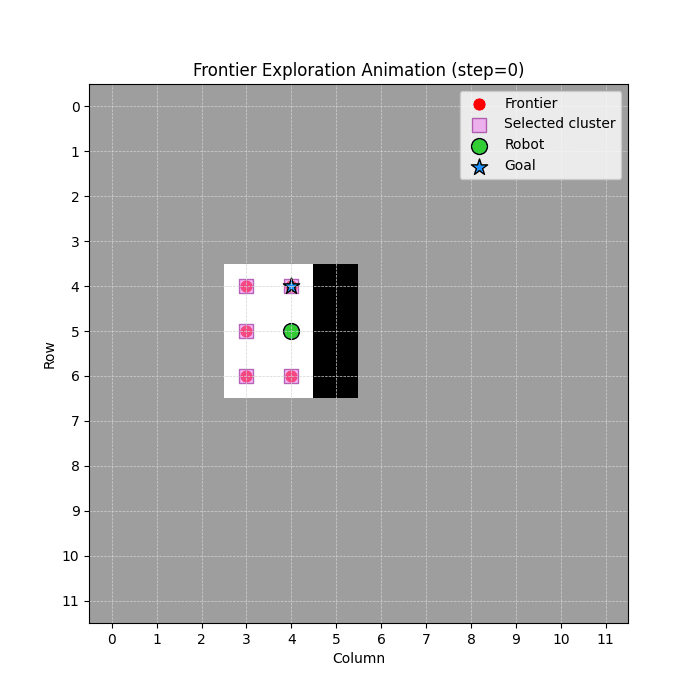

In [77]:
from pathlib import Path
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display


def run_exploration_history(base_grid, start_pos=(5, 4), reveal_radius=1, safety_max_steps=500):
    """Run exploration and store frame data for GIF export."""
    true_map = np.where(base_grid == -1, 0, base_grid).copy()
    known_map = np.full_like(true_map, -1)

    robot_pos = start_pos
    assert true_map[robot_pos] == 0, "Start position must be on free space."

    reveal_cells(known_map, true_map, robot_pos, radius=reveal_radius)

    frames = []
    current_goal = None
    current_cluster = None
    step_idx = 0

    while np.any(known_map == -1):
        frontiers = detect_frontiers(known_map)

        # Save current frame before moving.
        frames.append({
            'known_map': known_map.copy(),
            'frontiers': list(frontiers),
            'robot_pos': robot_pos,
            'goal_pos': current_goal,
            'cluster_cells': list(current_cluster) if current_cluster else [],
            'step_idx': step_idx,
        })

        # Stop if unknown cells remain but no frontiers are reachable.
        if not frontiers:
            break

        # Pick or refresh goal when needed.
        if current_goal is None or robot_pos == current_goal:
            clusters = cluster_frontiers(frontiers, known_map.shape)
            best_cluster, _, _ = choose_best_cluster(clusters, robot_pos)
            current_cluster = best_cluster
            current_goal = choose_goal_from_cluster(best_cluster, robot_pos)

        # Update selected cluster and goal in the most recently saved frame.
        frames[-1]['cluster_cells'] = list(current_cluster) if current_cluster else []
        frames[-1]['goal_pos'] = current_goal

        # Move one step and reveal nearby cells.
        robot_pos = step_toward_goal(robot_pos, current_goal, true_map)
        reveal_cells(known_map, true_map, robot_pos, radius=reveal_radius)

        step_idx += 1
        if step_idx >= safety_max_steps:
            break

    # Save one final frame after the loop ends.
    final_frontiers = detect_frontiers(known_map)
    frames.append({
        'known_map': known_map.copy(),
        'frontiers': list(final_frontiers),
        'robot_pos': robot_pos,
        'goal_pos': current_goal,
        'cluster_cells': list(current_cluster) if current_cluster else [],
        'step_idx': step_idx,
    })

    return frames


# Generate frame history using the same logic as Step 8.
history = run_exploration_history(grid, start_pos=(5, 4), reveal_radius=1)
print(f'Frames captured: {len(history)}')

# Build matplotlib animation from saved frames.
fig, ax = plt.subplots(figsize=(7, 7))


def update(frame_idx):
    frame = history[frame_idx]
    draw_frame(
        ax,
        frame['known_map'],
        frame['frontiers'],
        frame['robot_pos'],
        frame['goal_pos'],
        frame['step_idx'],
        frame['cluster_cells'],
    )


ani = FuncAnimation(fig, update, frames=len(history), interval=350, repeat=False)

# Save GIF in the current notebook working directory.
# This avoids path errors if the notebook is launched from different folders.
gif_path = (Path.cwd() / 'frontier_exploration.gif').resolve()
gif_path.parent.mkdir(parents=True, exist_ok=True)
ani.save(str(gif_path), writer=PillowWriter(fps=3))
plt.close(fig)

print(f'GIF saved to: {gif_path}')
display(Image(filename=str(gif_path)))